# High-Resolution Digital Terrain Model (DTM) Analysis

This notebook demonstrates terrain analysis techniques using high-resolution Digital Terrain Models (DTMs). The aim is to derive topographic attributes that describe surface morphology and see how this might influence environmental processes.

The workflow includes:

- Loading a previously extracted DTM
- Displaying topographic attributes

**Deriving and visualising terrain attributes, including:**

- Slope – Quantifies the rate of elevation change and represents terrain steepness.

- Aspect – Indicates the direction of maximum slope (e.g. north-facing, south-facing).

- Profile Curvature – Describes curvature in the direction of slope and affects the acceleration and deceleration of surface flow.

- Plan Curvature –  Influences lateral water flow and erosion.

These attributes form the basis for further analyses hydrological and canopy analysis.

## Loading WhiteboxTools
We begin by importing `whitebox`, initializing the toolset.

In [ ]:
import whitebox

wbt = whitebox.WhiteboxTools()  # Create WhiteboxTools object
wbt.set_verbose_mode(False)  # Disable detailed logging


0

In [2]:
# and additional required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import os
import rasterio

In [3]:
# Check WhiteboxTools version
print("WhiteboxTools Version:", wbt.version())

# Print the WhiteboxTools working directory
print("WhiteboxTools Directory:", wbt.work_dir)

WhiteboxTools Version: WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023

WhiteboxTools is an advanced geospatial data analysis platform developed at
the University of Guelph's Geomorphometry and Hydrogeomatics Research 
Group (GHRG). See www.whiteboxgeo.com for more details.

WhiteboxTools Directory: 


In [12]:
# set our working directory for data inputs
data_dir = os.path.join(os.getcwd(), 'GIthub/data/nrfa_39088')
wbt.set_working_dir(data_dir)

In [4]:
# Define input varibales as global constants
extracted_dem= 'dtm_39088_extract.tif'

## We can call the raster plotting function again

In [19]:

def plot_raster_with_histogram(raster_path: str, title: str, label: str, color_scheme: str):
    """ 
    Plot a raster with real-world extent, colour scaling and histogram.

    Parameters:
    raster_path : str
        Path to raster file
    title : str
        Title for the plot
    """

    # Load raster with rasterio to get georeferencing
    with rasterio.open(raster_path) as src:
        raster = src.read(1)  # Read the first band
        bounds = src.bounds  # Get raster bounding box
        nodata = src.nodata  # NoData value

    # Mask out NoData values
    if nodata is not None:
        valid_data = raster[raster != nodata]
    else:
        valid_data = raster[~np.isnan(raster)]

    if valid_data.size == 0:
        raise ValueError("No valid raster values found.")

    # Compute Color Normalization
    datamin = np.percentile(valid_data, 2)
    datamax = np.percentile(valid_data, 98)
    norm = colors.Normalize(vmin=datamin, vmax=datamax)
    cmap = color_scheme

    # Compute Real-World Extent
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Plot
    _, ax = plt.subplots(figsize=(10, 6))

    # Display the raster with real-world extent
    img = ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")

    # Display the raster with real-world extent #img =
    ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(title)
    
    # Create a colorbar
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(label)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = ax.inset_axes([1.3, 0.35, 0.06, 0.5])  # Position the colorbar inset
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=8)
    cax.yaxis.set_ticks_position('right')
    cax.yaxis.set_label_position('right')

    # Histogram inset
    hax = ax.inset_axes([1.2, 0.05, 0.25, 0.25])
    colormap = plt.colormaps.get_cmap(cmap)

    # Filter raster values for histogram
    data = valid_data[(valid_data > datamin) & (valid_data < datamax)]

    # Plot % histogram
    n = len(data)
    _, bins, patches = hax.hist(data, bins=20, edgecolor='none', weights=np.ones(n)/n*100)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Normalize bin centers to [0, 1]
    col = (bin_centers - min(bin_centers)) / (max(bin_centers) - min(bin_centers))

    for c, p in zip(col, patches):
            plt.setp(p, 'facecolor', colormap(c))

    hax.set_xlabel('Elevation (m)')
    hax.set_ylabel('Occupation (%)')
    hax.yaxis.set_ticks_position('right')
    hax.yaxis.set_label_position('right')

    plt.tight_layout()
    plt.show()


Now let's generate some terrain features using the WhiteboxTool library and plot the outputs
using our plot_raster function
### Slope

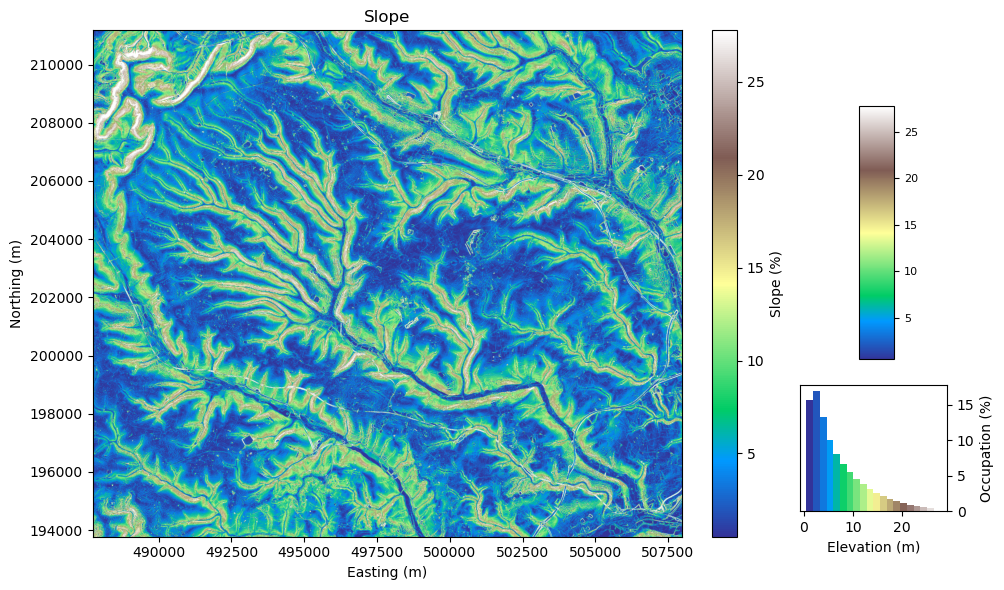

In [22]:
wbt.slope(dem=extracted_dem, output="slope.tif", units="percent")
plot_raster_with_histogram(f"{data_dir}/slope.tif", title='Slope', label="Slope (%)", color_scheme = 'terrain')

### Aspect

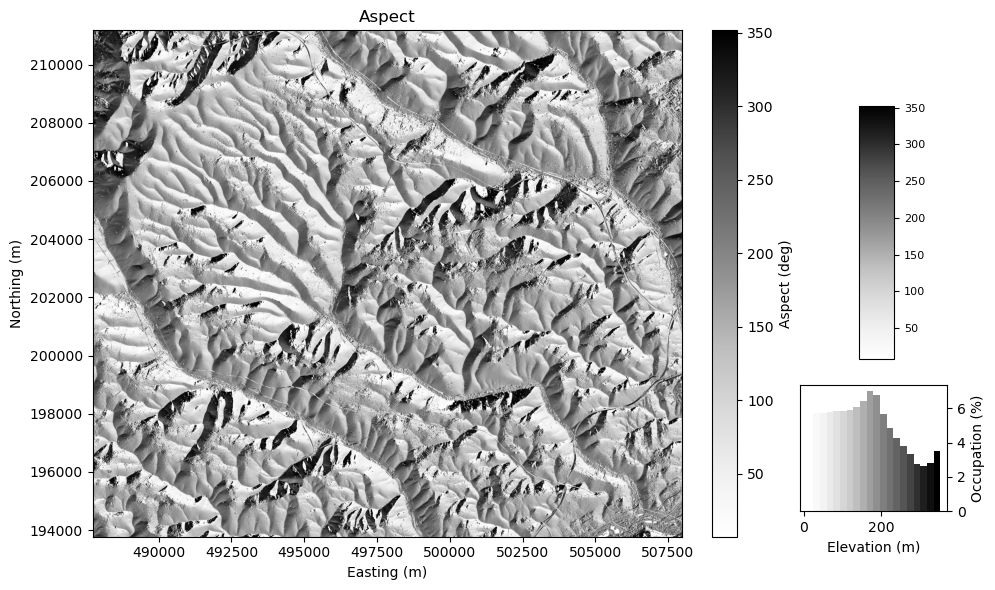

In [23]:
wbt.aspect(dem=extracted_dem, output="aspect.tif")
plot_raster_with_histogram(f"{data_dir}/aspect.tif", title = 'Aspect', label="Aspect (deg)", color_scheme="Grays")

### Profile Curvature

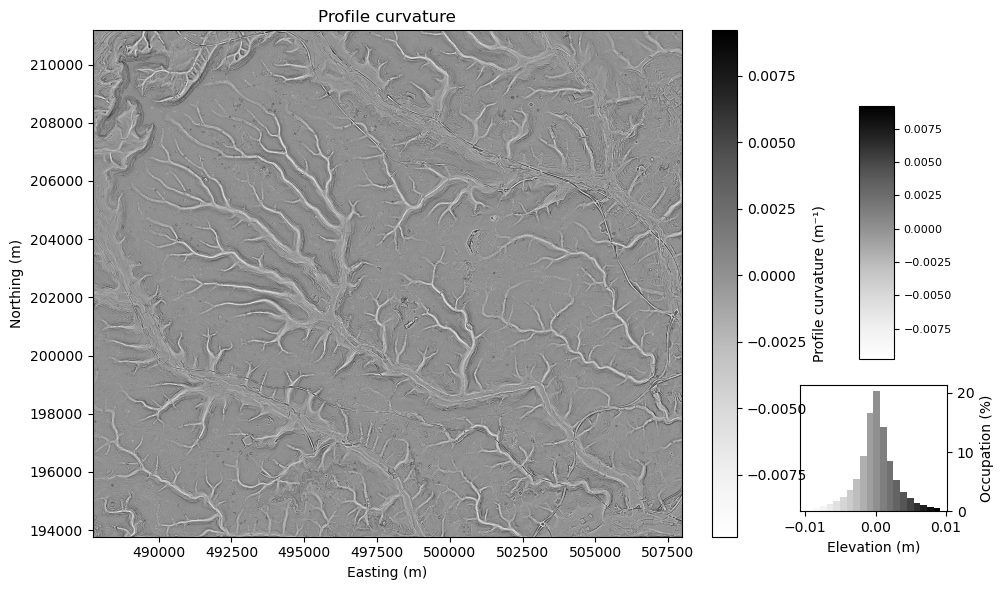

In [24]:
wbt.profile_curvature(dem='extracted_dem', output="profile_curv.tif")
plot_raster_with_histogram(f"{data_dir}/profile_curv.tif", title ='Profile curvature', label="Profile curvature (m⁻¹)", 
                           color_scheme="Greys")

### Plan curvature

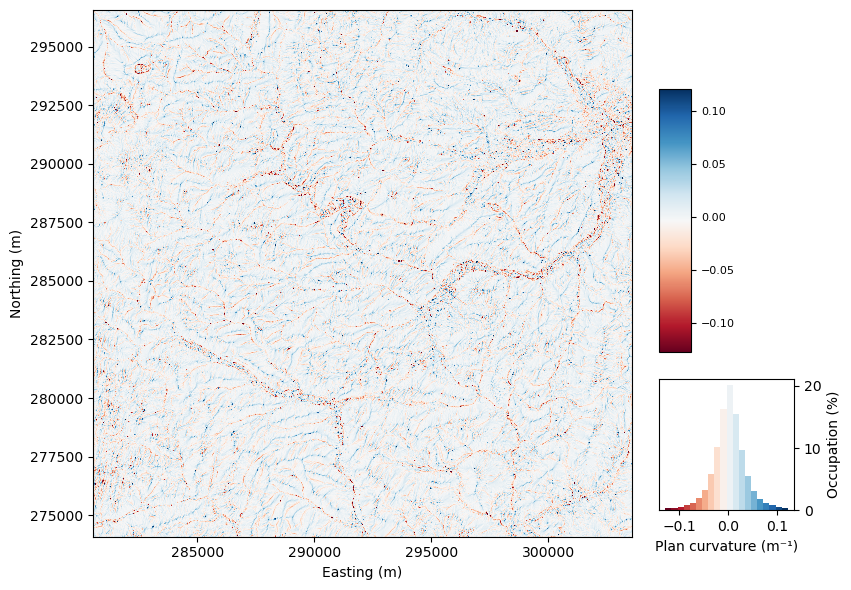

In [ ]:
wbt.plan_curvature(dem=extracted_dem, output="plan_curv.tif")
plot_raster_with_histogram(f"{data_dir}/plan_curv.tif", label="Plan curvature (m⁻¹)", color_scheme="RdBu")